# Week 2 Internship Task
## Deep Exploratory Analysis & Feature Engineering

### Dataset
Steel Industry Energy Consumption Dataset

### Objective
This notebook performs deep exploratory data analysis, feature engineering,
outlier detection, correlation analysis, and visualization of energy consumption
patterns in a steel manufacturing plant.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
!wget -O steel_energy.zip "https://archive.ics.uci.edu/static/public/851/steel+industry+energy+consumption.zip"

print("Dataset downloaded successfully!")

--2026-08-11 09:58:45--  https://archive.ics.uci.edu/static/public/851/steel+industry+energy+consumption.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘steel_energy.zip’

steel_energy.zip        [ <=>                ] 470.68K  --.-KB/s    in 0.1s    

2026-08-11 09:58:45 (3.40 MB/s) - ‘steel_energy.zip’ saved [481973]

Dataset downloaded successfully!


In [3]:
!unzip -o steel_energy.zip

Archive:  steel_energy.zip
  inflating: Steel_industry_data.csv  


In [4]:
!ls

sample_data  steel_energy.zip  Steel_industry_data.csv


In [5]:
import os

for root, dirs, files_list in os.walk("."):
    for file in files_list:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

./Steel_industry_data.csv
./sample_data/mnist_test.csv
./sample_data/california_housing_test.csv
./sample_data/mnist_train_small.csv
./sample_data/california_housing_train.csv


In [6]:
import pandas as pd

df = pd.read_csv("Steel_industry_data.csv")

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

Dataset loaded successfully!
Shape of dataset: (35040, 11)


In [7]:
df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 
dtypes: float64(6), 

In [9]:
print("Column names:")
for i, column in enumerate(df.columns, 1):
    print(i, "->", column)

Column names:
1 -> date
2 -> Usage_kWh
3 -> Lagging_Current_Reactive.Power_kVarh
4 -> Leading_Current_Reactive_Power_kVarh
5 -> CO2(tCO2)
6 -> Lagging_Current_Power_Factor
7 -> Leading_Current_Power_Factor
8 -> NSM
9 -> WeekStatus
10 -> Day_of_week
11 -> Load_Type


In [10]:
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y %H:%M')

print("Date converted successfully!")
print(df['date'].dtype)

Date converted successfully!
datetime64[ns]


In [11]:
# Extract hour of the day
df['Hour'] = df['date'].dt.hour

# Extract day of the week
df['Day_of_Week_Extracted'] = df['date'].dt.dayofweek

# Extract month
df['Month'] = df['date'].dt.month

# Identify weekday or weekend
df['Day_Type'] = df['date'].dt.dayofweek.apply(
    lambda x: 'Weekend' if x >= 5 else 'Weekday'
)

print("New time-based features created successfully!")

New time-based features created successfully!


In [12]:
print(df[['date', 'Hour', 'Day_of_Week_Extracted', 'Month', 'Day_Type']].head(10))

                 date  Hour  Day_of_Week_Extracted  Month Day_Type
0 2018-01-01 00:15:00     0                      0      1  Weekday
1 2018-01-01 00:30:00     0                      0      1  Weekday
2 2018-01-01 00:45:00     0                      0      1  Weekday
3 2018-01-01 01:00:00     1                      0      1  Weekday
4 2018-01-01 01:15:00     1                      0      1  Weekday
5 2018-01-01 01:30:00     1                      0      1  Weekday
6 2018-01-01 01:45:00     1                      0      1  Weekday
7 2018-01-01 02:00:00     2                      0      1  Weekday
8 2018-01-01 02:15:00     2                      0      1  Weekday
9 2018-01-01 02:30:00     2                      0      1  Weekday


In [13]:
print("Updated dataset shape:", df.shape)
print("\nUpdated columns:")
print(df.columns.tolist())

Updated dataset shape: (35040, 15)

Updated columns:
['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type', 'Hour', 'Day_of_Week_Extracted', 'Month', 'Day_Type']


In [14]:
# Create Power Factor Ratio
df['Power_Factor_Ratio'] = (
    df['Leading_Current_Power_Factor'] /
    df['Lagging_Current_Power_Factor']
)

print("Power Factor Ratio created successfully!")

Power Factor Ratio created successfully!


In [15]:
df[['Leading_Current_Power_Factor',
   'Lagging_Current_Power_Factor',
   'Power_Factor_Ratio']].head(10)

,Leading_Current_Power_Factor,Lagging_Current_Power_Factor,Power_Factor_Ratio
0,100.0,73.21,1.365934
1,100.0,66.77,1.497679
2,100.0,70.28,1.422880
3,100.0,68.09,1.468644
4,100.0,64.72,1.545117
5,100.0,67.76,1.475797
6,100.0,65.62,1.523926
7,100.0,64.37,1.553519
8,100.0,66.94,1.493875
9,100.0,62.51,1.599744


In [16]:
# Calculate the 75th percentile of Usage_kWh
usage_75th_percentile = df['Usage_kWh'].quantile(0.75)

print("75th percentile of Usage_kWh:", usage_75th_percentile)

75th percentile of Usage_kWh: 51.2375


In [17]:
# Create High Load feature
df['High_Load'] = (df['Usage_kWh'] > usage_75th_percentile).astype(int)

print("High Load feature created successfully!")

High Load feature created successfully!


In [18]:
print(df[['Usage_kWh', 'High_Load']].head(20))

    Usage_kWh  High_Load
0        3.17          0
1        4.00          0
2        3.24          0
3        3.31          0
4        3.82          0
5        3.28          0
6        3.60          0
7        3.60          0
8        3.28          0
9        3.78          0
10       3.46          0
11       3.24          0
12       3.96          0
13       3.31          0
14       3.31          0
15       3.89          0
16       3.28          0
17       3.56          0
18       3.74          0
19       3.31          0


In [19]:
print("\nHigh Load distribution:")
print(df['High_Load'].value_counts())


High Load distribution:
High_Load
0    26280
1     8760
Name: count, dtype: int64


In [20]:
print("Current dataset shape:", df.shape)

print("\nEngineered features:")
print([
    'Hour',
    'Day_of_Week_Extracted',
    'Month',
    'Day_Type',
    'Power_Factor_Ratio',
    'High_Load'
])

Current dataset shape: (35040, 17)

Engineered features:
['Hour', 'Day_of_Week_Extracted', 'Month', 'Day_Type', 'Power_Factor_Ratio', 'High_Load']


In [21]:
# Calculate Q1 and Q3
Q1 = df['Usage_kWh'].quantile(0.25)
Q3 = df['Usage_kWh'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Calculate lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 3.2
Q3: 51.2375
IQR: 48.037499999999994
Lower Bound: -68.85624999999999
Upper Bound: 123.29374999999999


In [23]:
# Identify outliers
outliers = df[
    (df['Usage_kWh'] < lower_bound) |
    (df['Usage_kWh'] > upper_bound)
]

print("Number of outliers:", len(outliers))

Number of outliers: 328


In [24]:
print("Outlier Usage_kWh values:")
print(outliers['Usage_kWh'].describe())

Outlier Usage_kWh values:
count    328.000000
mean     131.541555
std        6.576109
min      123.300000
25%      126.162500
50%      129.940000
75%      135.160000
max      157.180000
Name: Usage_kWh, dtype: float64


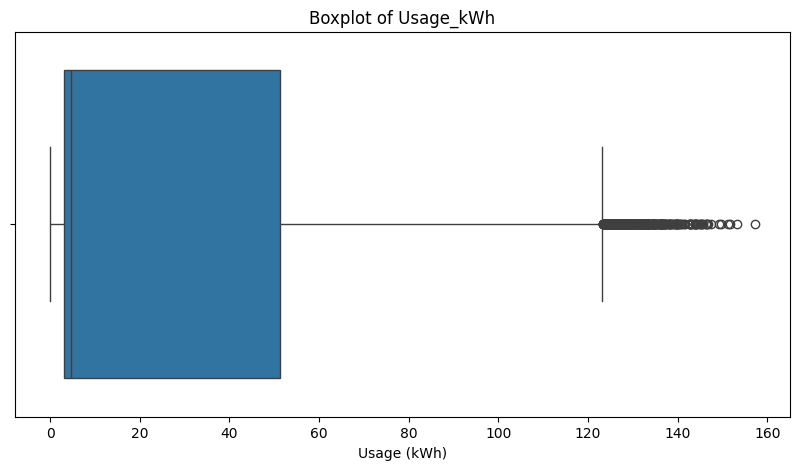

In [25]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df['Usage_kWh'])

plt.title('Boxplot of Usage_kWh')
plt.xlabel('Usage (kWh)')

plt.show()

### Outlier Analysis

Outliers in `Usage_kWh` were detected using the Interquartile Range (IQR) method.
Values below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR were classified as outliers.
The boxplot provides a visual representation of the distribution of energy
consumption and highlights observations that fall outside the normal range.

In [26]:
# Select all numerical columns
numerical_df = df.select_dtypes(include=np.number)

# Calculate correlation matrix
correlation_matrix = numerical_df.corr()

print("Correlation matrix created successfully!")
correlation_matrix

Correlation matrix created successfully!


,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Hour,Day_of_Week_Extracted,Month,Power_Factor_Ratio,High_Load
Usage_kWh,1.000000,0.896150,-0.324922,0.988180,0.385960,0.353566,2.346103e-01,2.341748e-01,-2.407046e-01,-1.139607e-01,-0.090094,0.867840
Lagging_Current_Reactive.Power_kVarh,0.896150,1.000000,-0.405142,0.886948,0.144534,0.407716,8.266237e-02,8.125047e-02,-2.562275e-01,-4.213561e-02,0.075592,0.825672
Leading_Current_Reactive_Power_kVarh,-0.324922,-0.405142,1.000000,-0.332777,0.526770,-0.944039,3.716046e-01,3.727349e-01,2.129219e-01,-2.709951e-02,-0.779884,-0.294913
CO2(tCO2),0.988180,0.886948,-0.332777,1.000000,0.379605,0.360019,2.317260e-01,2.313063e-01,-2.352975e-01,-1.083105e-01,-0.082349,0.863164
Lagging_Current_Power_Factor,0.385960,0.144534,0.526770,0.379605,1.000000,-0.519967,5.652695e-01,5.665439e-01,4.246488e-02,-8.705239e-02,-0.915117,0.285679
Leading_Current_Power_Factor,0.353566,0.407716,-0.944039,0.360019,-0.519967,1.000000,-3.605630e-01,-3.614087e-01,-2.576774e-01,-3.232157e-02,0.805223,0.296275
NSM,0.234610,0.082662,0.371605,0.231726,0.565270,-0.360563,1.000000e+00,9.991858e-01,-1.052838e-16,2.297820e-15,-0.530254,0.177164
Hour,0.234175,0.081250,0.372735,0.231306,0.566544,-0.361409,9.991858e-01,1.000000e+00,1.014784e-17,-6.087321e-16,-0.531380,0.176399
Day_of_Week_Extracted,-0.240705,-0.256227,0.212922,-0.235298,0.042465,-0.257677,-1.052838e-16,1.014784e-17,1.000000e+00,1.252494e-02,-0.141698,-0.235285
Month,-0.113961,-0.042136,-0.027100,-0.108311,-0.087052,-0.032322,2.297820e-15,-6.087321e-16,1.252494e-02,1.000000e+00,0.062670,-0.068300


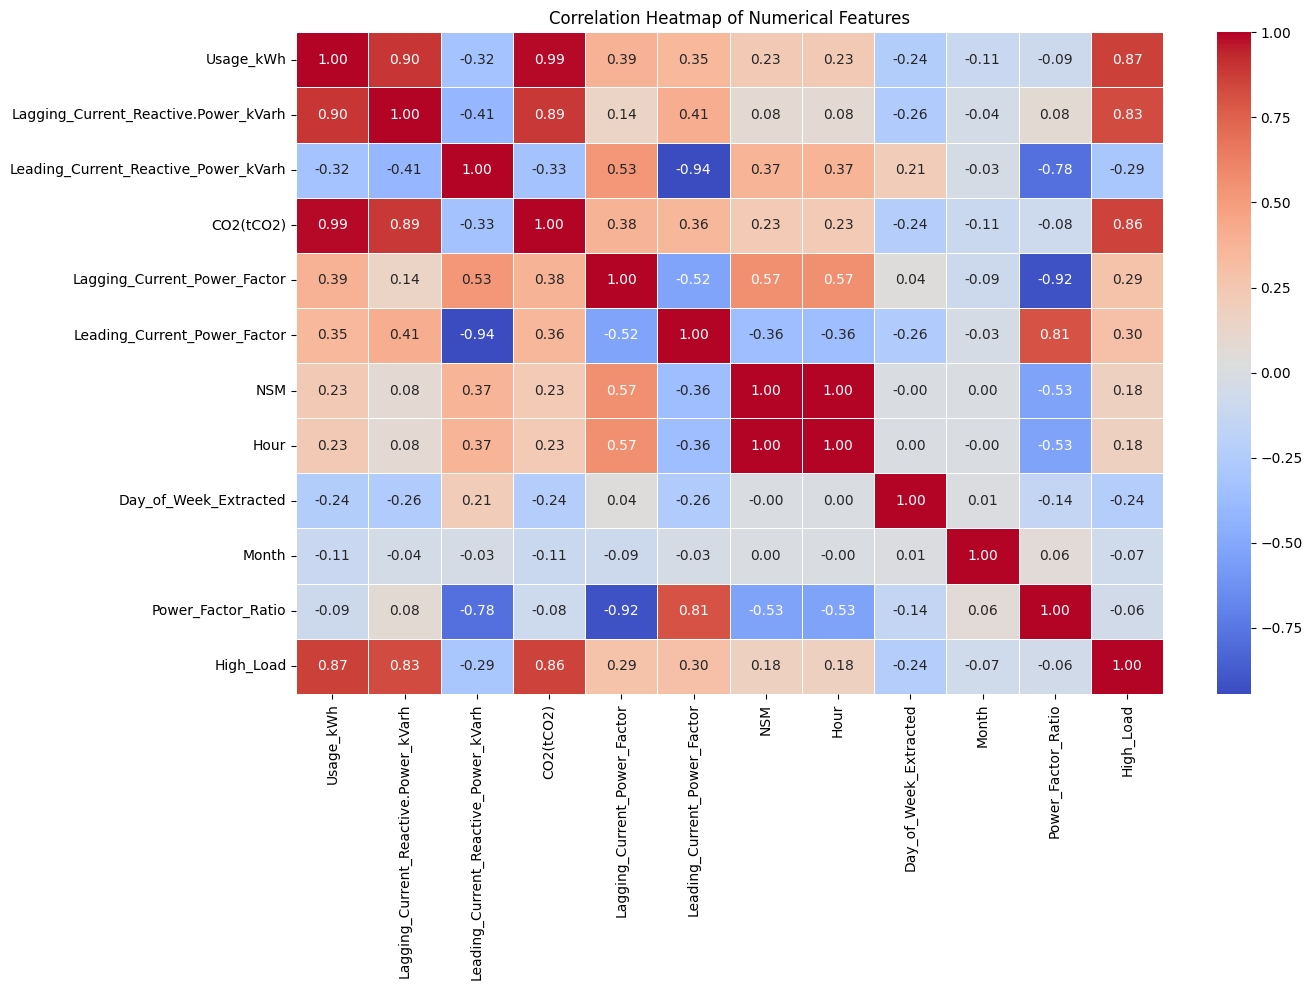

In [27]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

In [28]:
# Get correlations with Usage_kWh
usage_correlations = correlation_matrix['Usage_kWh'].drop('Usage_kWh')

# Sort by absolute correlation
top_3_features = usage_correlations.abs().sort_values(ascending=False).head(3)

print("Top 3 features most correlated with Usage_kWh:")
print(top_3_features)

Top 3 features most correlated with Usage_kWh:
CO2(tCO2)                               0.98818
Lagging_Current_Reactive.Power_kVarh    0.89615
High_Load                               0.86784
Name: Usage_kWh, dtype: float64


In [29]:
print("Top 3 correlated features with Usage_kWh:\n")

for feature in top_3_features.index:
    correlation_value = usage_correlations[feature]
    print(f"{feature}: {correlation_value:.4f}")

Top 3 correlated features with Usage_kWh:

CO2(tCO2): 0.9882
Lagging_Current_Reactive.Power_kVarh: 0.8961
High_Load: 0.8678


### Correlation Analysis

A correlation heatmap was generated using all numerical features in the dataset.
The three features with the strongest absolute correlation with `Usage_kWh`
were identified from the correlation matrix. These relationships provide useful
initial insight into which variables may be associated with energy consumption.

In [30]:
# Calculate average energy consumption by Load Type
load_type_avg = df.groupby('Load_Type')['Usage_kWh'].mean().sort_values()

print("Average Energy Consumption by Load Type:")
print(load_type_avg)

Average Energy Consumption by Load Type:
Load_Type
Light_Load       8.626207
Medium_Load     38.445394
Maximum_Load    59.265314
Name: Usage_kWh, dtype: float64


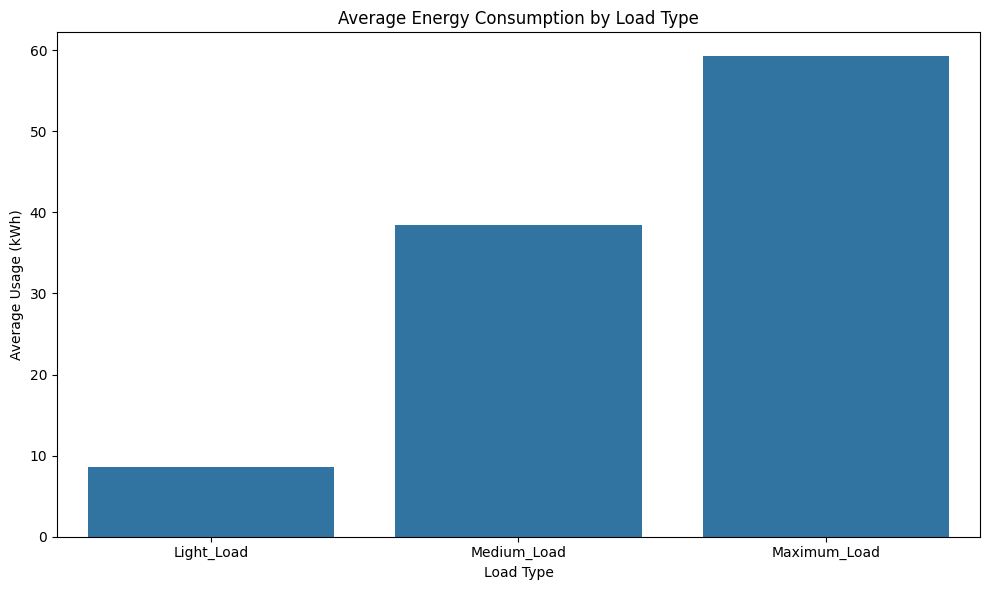

In [31]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=load_type_avg.index,
    y=load_type_avg.values
)

plt.title('Average Energy Consumption by Load Type')
plt.xlabel('Load Type')
plt.ylabel('Average Usage (kWh)')

plt.tight_layout()
plt.show()

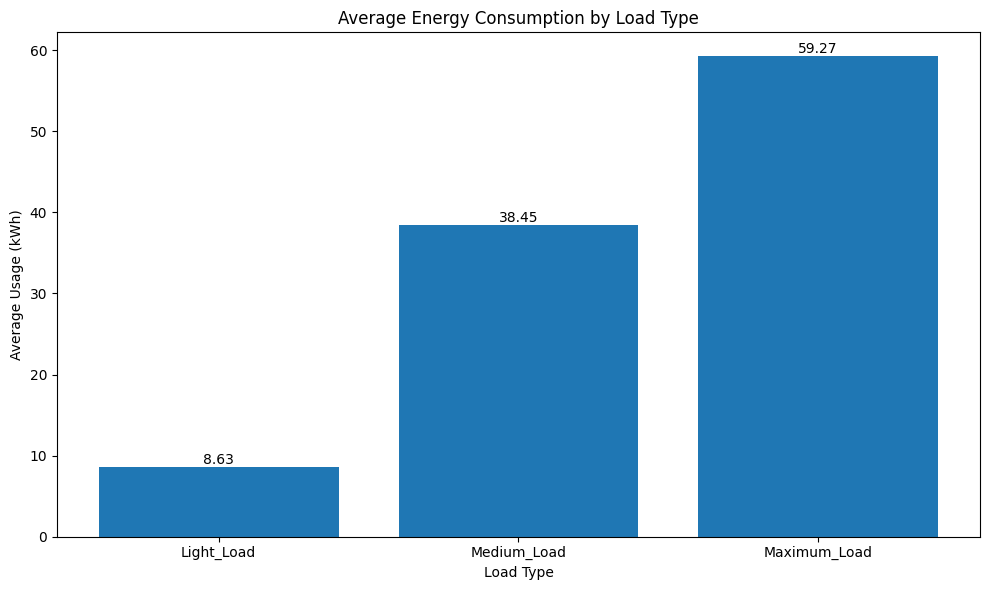

In [32]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    load_type_avg.index,
    load_type_avg.values
)

plt.title('Average Energy Consumption by Load Type')
plt.xlabel('Load Type')
plt.ylabel('Average Usage (kWh)')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

### Energy Consumption by Load Type

The average energy consumption was calculated separately for Light Load,
Medium Load, and Maximum Load. The grouped bar chart allows comparison of
energy usage across the three load categories and helps identify which type
of load is associated with higher average energy consumption.

In [33]:
# Calculate average energy usage for each hour
hourly_usage = df.groupby('Hour')['Usage_kWh'].mean()

print("Average Energy Usage by Hour:")
print(hourly_usage)

Average Energy Usage by Hour:
Hour
0      7.870075
1      6.072479
2      4.428390
3      4.358041
4      4.309438
5      4.245548
6      4.223705
7      4.502075
8     37.704795
9     58.551733
10    55.874733
11    57.097459
12    18.461000
13    39.019500
14    56.155260
15    55.637541
16    55.799582
17    43.833096
18    33.020932
19    38.208514
20    37.477226
21    13.777363
22     8.658918
23     7.998014
Name: Usage_kWh, dtype: float64


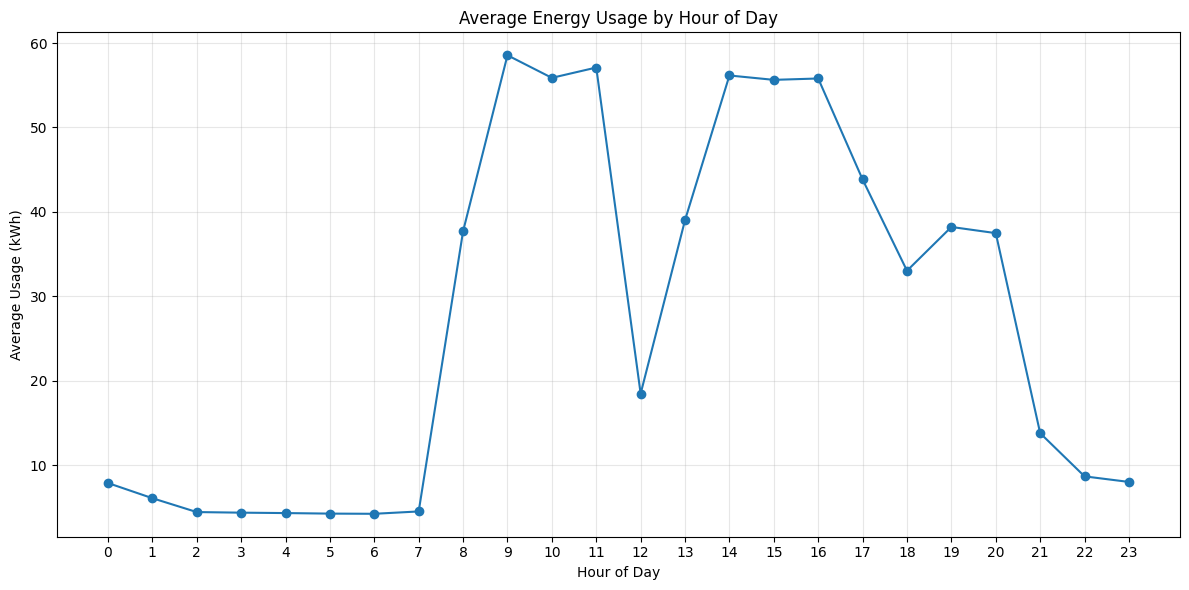

In [34]:
plt.figure(figsize=(12, 6))

plt.plot(
    hourly_usage.index,
    hourly_usage.values,
    marker='o'
)

plt.title('Average Energy Usage by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Usage (kWh)')

plt.xticks(range(24))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
highest_hour = hourly_usage.idxmax()
highest_usage = hourly_usage.max()

lowest_hour = hourly_usage.idxmin()
lowest_usage = hourly_usage.min()

print(f"Highest average usage: {highest_usage:.2f} kWh at hour {highest_hour}:00")
print(f"Lowest average usage: {lowest_usage:.2f} kWh at hour {lowest_hour}:00")

Highest average usage: 58.55 kWh at hour 9:00
Lowest average usage: 4.22 kWh at hour 6:00


### Hourly Energy Usage Pattern

The line chart shows the variation in average energy consumption across
different hours of the day. This helps identify periods of relatively high
and low energy demand and provides insight into the daily operating pattern
of the steel manufacturing plant.

## EDA Summary

The Steel Industry Energy Consumption dataset contains 35,040 observations and 11 original columns. During the exploratory analysis, the dataset was examined for structure, data types, missing values, outliers, correlations, and consumption patterns. The date column was converted into datetime format, and additional time-based features including hour, day of week, month, and weekday/weekend status were created. No missing values were identified in the dataset. Using the IQR method, 328 outliers were detected in Usage_kWh, with the outlier values ranging from approximately 123.30 to 157.18 kWh. These observations were retained because the task required detection and visualization rather than removal.

The correlation analysis showed that CO2(tCO2) had the strongest correlation with Usage_kWh at 0.9882, followed by Lagging_Current_Reactive.Power_kVarh at 0.8961. High_Load also showed a strong correlation of 0.8678; however, this feature was derived directly from Usage_kWh and therefore represents target leakage for later modeling.

A clear pattern was observed across load types. Maximum Load had the highest average consumption at 59.27 kWh, followed by Medium Load at 38.45 kWh and Light Load at 8.63 kWh. The hourly analysis showed strong variation throughout the day. Average usage was lowest at 6:00, with 4.22 kWh, and reached its highest value at 9:00, with 58.55 kWh.

One possible hypothesis is that energy spikes are mainly driven by periods of higher industrial production and electrical load. Increased machine operation may increase power consumption, reactive power demand, and associated CO2 emissions, resulting in higher energy usage during peak operating periods.

In [36]:
# Save the engineered dataset for Part 2

df.to_csv("steel_energy_engineered.csv", index=False)

print("Engineered dataset saved successfully!")
print("File: steel_energy_engineered.csv")
print("Shape:", df.shape)

Engineered dataset saved successfully!
File: steel_energy_engineered.csv
Shape: (35040, 17)


In [37]:
import os

print("File exists:", os.path.exists("steel_energy_engineered.csv"))
print("File size:", os.path.getsize("steel_energy_engineered.csv"), "bytes")

File exists: True
File size: 4156062 bytes


In [38]:
from google.colab import files

files.download("steel_energy_engineered.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>